# Hotel Booking Cancellation Prediction | Decision Tree

Can booking information help flag cancellations before the final reservation outcome is known?

This notebook works through that question with an interpretable Decision Tree. The focus is not just the final score; I also check data quality, remove leakage, handle identifier-like features carefully, compare an unrestricted tree with a tuned one, and look at what the model actually learned.

## 1. Project Overview

Hotel cancellations make revenue forecasting and room planning harder. A useful model should therefore do more than classify reservations correctly: it should also make clear where its errors come from and whether its decision rules generalize beyond the training data.

**Problem type:** Binary Classification  
**Target:** `is_canceled`

- `0` → reservation was not cancelled
- `1` → reservation was cancelled

### Prediction Scope

I frame this as a **pre-arrival operational risk model** using the latest reservation information available before the final outcome is known.

This is different from predicting cancellation at the exact moment a booking is created. If that were the deployment point, any feature that can change later in the booking lifecycle would need another availability review.

## 2. Why a Decision Tree?

I chose a Decision Tree because cancellation risk is unlikely to follow a simple linear pattern. A tree can capture interactions between booking characteristics while still giving us decision rules that are easy to inspect.

That trade-off is useful here. I can see which variables drive the early splits, compare feature importance, and also observe one of the main weaknesses of a single tree directly: if it is allowed to grow freely, it can overfit very quickly.

## 3. Import Libraries

In [1]:
import colorsys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap, to_rgb

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import ( accuracy_score, classification_report,  confusion_matrix,
                              f1_score, precision_score, recall_score, )
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree


# Portfolio palette
PRIMARY = "#4C72B0"      # blue
SECONDARY = "#55A868"    # green
ACCENT = "#C44E52"       # emphasis / warnings
NEUTRAL = "#7F7F7F"      # gray

correlation_cmap = LinearSegmentedColormap.from_list(
    "portfolio_blue_green",
    [PRIMARY, "#F2F2F2", SECONDARY],
)

## 4. Load Dataset

The loading cell checks a few common local paths first and then looks inside Kaggle's input directory.

That keeps the notebook portable without tying it to one machine-specific file path.

In [2]:
candidate_paths = [
    Path("hotel_bookings.csv"),
    Path("data/hotel_bookings.csv"),
    Path("../data/hotel_bookings.csv"),]

kaggle_input = Path("/kaggle/input")

if kaggle_input.exists():
    candidate_paths.extend(kaggle_input.glob("**/hotel_bookings.csv"))

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Could not find hotel_bookings.csv. Place it in the project data folder "
        "or attach the dataset in Kaggle."
    )

print(f"Dataset loaded from: {data_path}")

df = pd.read_csv(data_path)
df.head()

Dataset loaded from: ..\data\hotel_bookings.csv


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### Quick Sanity Check

The first five rows are only a structural check. I use them to confirm that the expected columns are present, categorical values look sensible, and the target is loaded in the expected form before moving into analysis.

## 5. Initial Data Validation

In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 119,390
Columns: 32


### Why Dataset Size Matters

The dataset contains **119,390 rows and 32 original columns**.

That is large enough to keep a separate test set while still using cross-validation on the training data, so the evaluation does not have to depend on a very small sample.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

### What the Schema Tells Us

Before cleaning, the dataset contains a mix of numerical and categorical fields, plus a small number of columns with missing values.

This check matters because the preprocessing strategy should follow the meaning and data type of each feature rather than applying the same transformation everywhere.

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0


### What I Look For in the Summary

The descriptive table is a quick way to spot unusual ranges, dominant categories, and variables that deserve a closer look.

I treat it as a diagnostic step rather than a source of conclusions on its own.

In [6]:
duplicate_count = df.duplicated().sum()
print(f"Exact duplicate rows: {duplicate_count:,}")

Exact duplicate rows: 31,994


### Duplicate Check

The raw dataset contains **31,994 exact duplicate rows**, which is too large to ignore.

I do not remove them automatically because the dataset has no unique booking identifier. Two separate reservations can therefore have exactly the same recorded attributes.

There is still an evaluation concern. That count is roughly 27% of all rows, and it is measured on the raw columns, so it can only stay the same or grow once some columns are dropped later. With a random train/test split, identical rows can land on both sides, which may make the held-out score optimistic. A very deep tree is the model most likely to benefit, because it can simply memorize repeated patterns. I keep the rows in this version, but re-running everything without duplicates is the first follow-up I would do.

## 6. Exploratory Data Analysis

### 6.1 Target Distribution

Before fitting a classifier, I want to know how common cancellations actually are. A heavily imbalanced target can make Accuracy look stronger than the model really is.

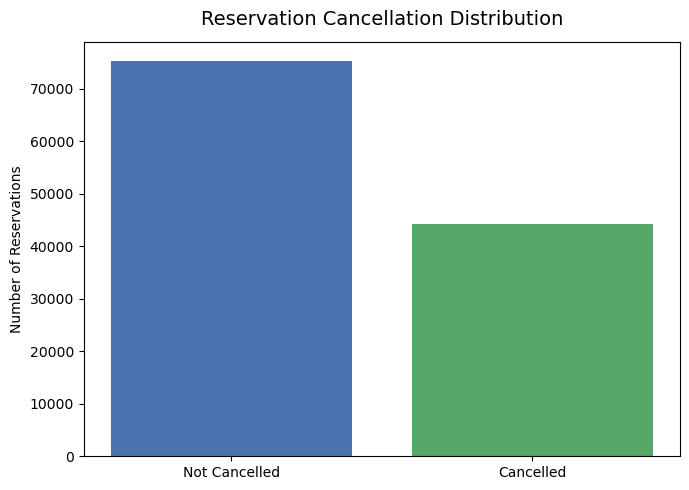

,Percentage
Not Cancelled,62.96
Cancelled,37.04


In [7]:
plt.figure(figsize=(7, 5))

counts = df["is_canceled"].value_counts().sort_index()

plt.bar( ["Not Cancelled", "Cancelled"], counts.values, color=[PRIMARY, SECONDARY] )
plt.title("Reservation Cancellation Distribution", fontsize=14, pad=12)
plt.ylabel("Number of Reservations")
plt.tight_layout()
plt.show()

target_share = (df["is_canceled"].value_counts(normalize=True).sort_index()
                .rename(index={0: "Not Cancelled", 1: "Cancelled"}).mul(100).round(2))
target_share.to_frame("Percentage")

### What the Class Balance Means

About **62.96%** of reservations were not cancelled and **37.04%** were cancelled.

That is an imbalance, but not an extreme one. I therefore report Accuracy together with Precision, Recall, and F1 instead of relying on one headline metric.

Recall is especially useful here because it tells us how many real cancellations the model catches. Precision answers the other side of the question: when the model flags a cancellation, how often is it right?

### 6.2 Missing Values

The missing-value check is where the preprocessing decisions start to become feature-specific.

A missing company or agent code does not mean the same thing as a missing numerical measurement, so I do not want the tree itself—or one generic imputation rule—to make that distinction for me.

In [8]:
missing_summary = ( pd.DataFrame({ "Missing_Count": df.isna().sum(), "Missing_Percent": df.isna().mean() * 100 })
                    .query("Missing_Count > 0").sort_values("Missing_Percent", ascending=False) )

missing_summary

,Missing_Count,Missing_Percent
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


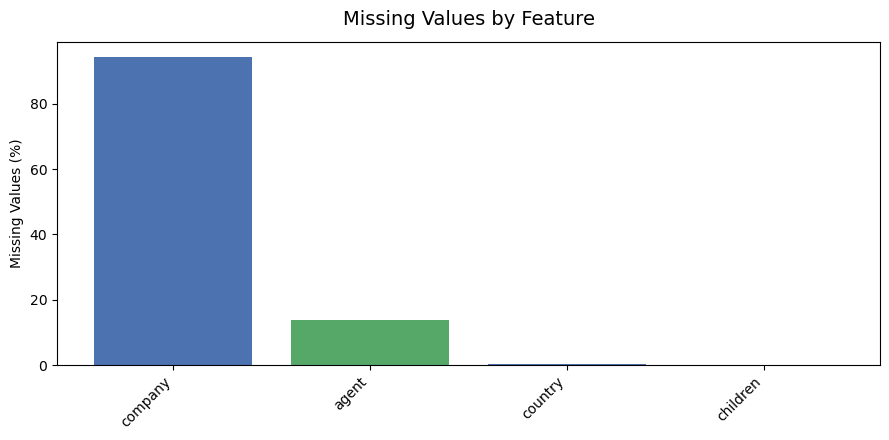

In [9]:
if not missing_summary.empty:
    plt.figure(figsize=(9, 4.5))
    plt.bar(
        missing_summary.index,
        missing_summary["Missing_Percent"],
        color=[PRIMARY, SECONDARY]
    )
    plt.title("Missing Values by Feature", fontsize=14, pad=12)
    plt.ylabel("Missing Values (%)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

### How Missing Values Are Handled

`company` is missing in **94.31%** of the rows. Because it is also an identifier rather than a continuous measurement, I exclude it from the modeling data.

`agent` is missing in about **13.69%** of rows. I keep it, but treat its codes as categories instead of numbers.

The remaining missing values are handled inside the preprocessing pipeline so that every imputation step is learned from training data only.

## 7. Data Leakage Prevention

`reservation_status` and `reservation_status_date` are removed before modeling because they are tied directly to the final reservation outcome.

Keeping them would let the model learn from information that would not be available when cancellation risk needs to be estimated. A high score under that setup would look impressive but would not represent a usable prediction workflow.

### Feature Availability

This project is framed as a **pre-arrival operational risk model**, but feature timing still matters.

`assigned_room_type` is excluded from the main model as a conservative choice. Its value can be finalized or updated relatively close to arrival, and the dataset does not provide enough timestamp detail to guarantee that it would be available consistently at every scoring point.

`reserved_room_type` remains available because it reflects the room type originally requested during the reservation process.

Other fields can also keep changing until arrival, for example `booking_changes`, `required_car_parking_spaces`, `total_of_special_requests`, and `adr`. I keep them under the pre-arrival framing, but they are part of this project's feature-availability limitation. A stricter booking-creation model would require another review of these fields.

In [10]:
outcome_leakage_columns = [
    "reservation_status",
    "reservation_status_date",
]

# Conservative timing choice:
# assigned_room_type may be updated close to arrival, so I exclude it
# from the main pre-arrival model.
timing_sensitive_columns = [
    "assigned_room_type",
]

columns_to_drop = outcome_leakage_columns + timing_sensitive_columns

df = df.drop(
    columns=[
        column
        for column in columns_to_drop
        if column in df.columns
    ]
)

print("Outcome-leakage columns removed:", outcome_leakage_columns)
print("Timing-sensitive columns removed:", timing_sensitive_columns)

Outcome-leakage columns removed: ['reservation_status', 'reservation_status_date']
Timing-sensitive columns removed: ['assigned_room_type']


## 8. Identifier Handling & Feature Engineering

### 8.1 Identifier Handling

Numeric storage does not always mean numeric meaning.

`company` and `agent` are IDs. Treating an agent code such as `240` as if it were a measurable quantity would give the tree an artificial ordering that does not exist in the real world.

In [11]:
# `company` is mostly missing and behaves like an ID, so I exclude it.
if "company" in df.columns:
    company_missing_pct = df["company"].isna().mean() * 100
    print(f"company missing values: {company_missing_pct:.2f}%")
    df = df.drop(columns=["company"])

# `agent` is also an ID. Treat it as a category instead of a number.
if "agent" in df.columns:
    df["agent"] = (df["agent"].astype("Int64").astype("string").fillna("Unknown").astype(object))

    print(f"agent categories: {df['agent'].nunique(dropna=False):,}")
    print(f"agent dtype after conversion: {df['agent'].dtype}")

company missing values: 94.31%
agent categories: 334
agent dtype after conversion: object


### Why `agent` and `company` Need Special Treatment

I drop `company` because its identifier role is combined with more than 94% missing values.

I keep `agent`, but convert it to a categorical feature. That prevents rules such as `agent <= 7.5` and lets One-Hot Encoding represent individual agents without inventing a numeric scale.

There is still a trade-off. `agent` and `country` are high-cardinality categorical features, so One-Hot Encoding creates many binary columns. A Decision Tree may then learn very specific rules such as `agent_9 == 1` or `country_PRT == 1`, which can be useful in this dataset but may generalize poorly to a different hotel or booking system.

For this single-tree project I keep One-Hot Encoding because it is transparent and leakage-safe inside the pipeline. Rare-category grouping, frequency encoding, or carefully cross-validated target encoding are better candidates for a later comparison.

### 8.2 Feature Engineering

In [12]:
df["total_nights"] = (df["stays_in_weekend_nights"] + df["stays_in_week_nights"])

df["total_guests"] = (df["adults"] + df["children"].fillna(0) + df["babies"])

zero_guest_count = (df["total_guests"] == 0).sum()
zero_night_count = (df["total_nights"] == 0).sum()

print(f"Bookings with zero recorded guests: {zero_guest_count:,}")
print(f"Bookings with zero recorded nights: {zero_night_count:,}")

df[["total_nights", "total_guests"]].head()

Bookings with zero recorded guests: 180
Bookings with zero recorded nights: 715


,total_nights,total_guests
0,0,2.0
1,0,2.0
2,1,1.0
3,1,1.0
4,2,2.0


### Why These Two Features Are Useful

`total_nights` gives one readable measure of planned stay length, while `total_guests` summarizes party size.

The checks above found **180 bookings with zero recorded guests** and **715 bookings with zero recorded nights**. Both patterns deserve attention because they can represent unusual reservations, incomplete records, or valid edge cases depending on how the booking system was used.

I keep these rows because the dataset does not provide enough context to label them as errors with confidence. Rather than silently deleting them, I treat them as documented data-quality signals that can be revisited in a sensitivity analysis.

### 8.3 Correlation Analysis

I use Pearson correlation here as a descriptive check of **linear relationships between numerical variables**.

The Decision Tree does not require linear relationships, so the heatmap is not being used for feature selection. It is simply a compact way to spot strong numeric associations and possible redundancy.

After identifier handling, `agent` is no longer part of the numerical correlation matrix, and `company` has already been removed.

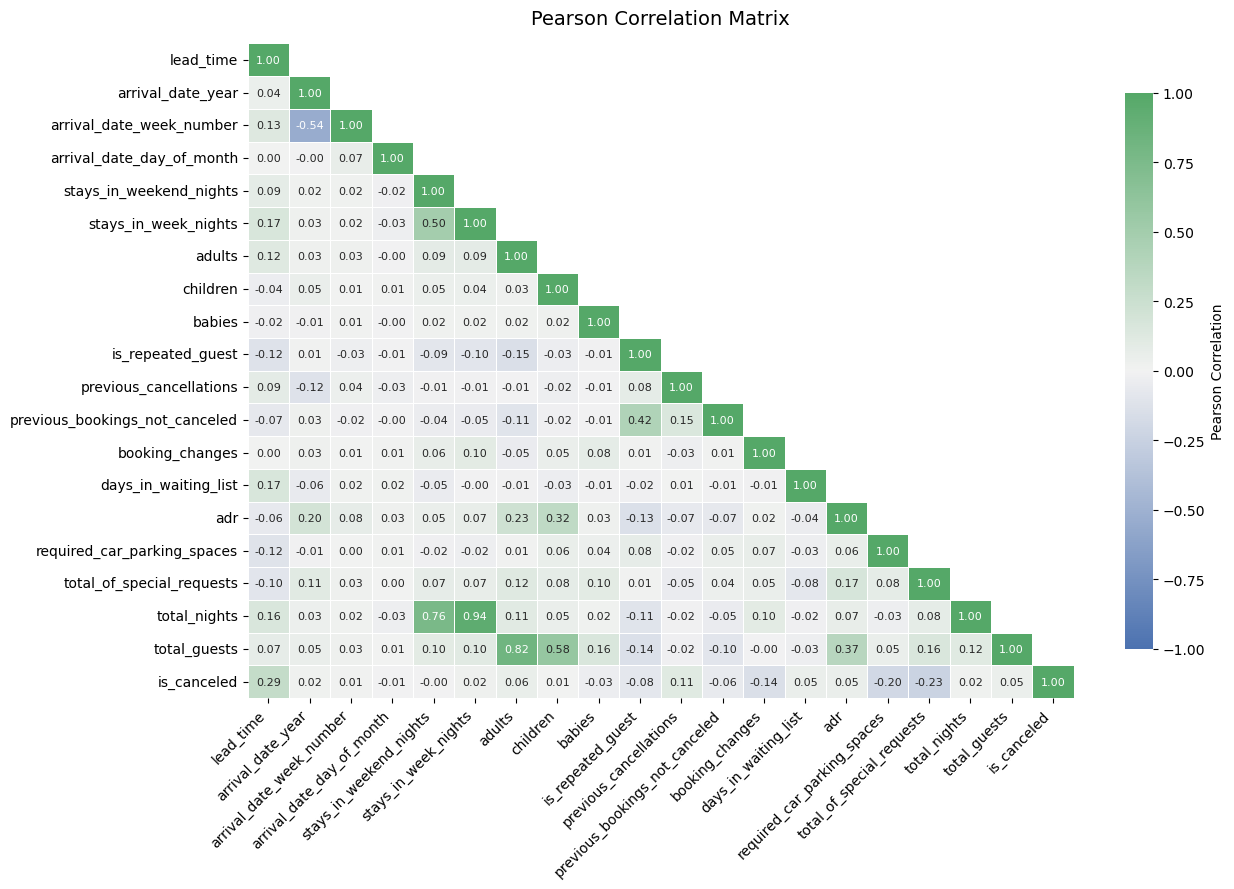

In [13]:
target = "is_canceled"

# Pearson correlation is used here as a descriptive linear-association check.
numeric_df = df.select_dtypes(include="number")

# Put the target last so the heatmap is easier to scan.
df_ordered = pd.concat([numeric_df.drop(columns=target), numeric_df[[target]]],axis=1,)

corr_matrix = df_ordered.corr(method="pearson")

# Hide the upper triangle because it duplicates the same correlations.
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1,)

plt.figure(figsize=(13, 9), dpi=100)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap=correlation_cmap,
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 8},
    cbar_kws={
        "shrink": 0.85,
        "label": "Pearson Correlation",
    },
)

plt.title("Pearson Correlation Matrix", fontsize=14, pad=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### How to Read the Correlation Matrix

A strong correlation means two numerical variables move together in a roughly linear way. It does not tell us that one causes the other.

For this project, I use the matrix as background context. The actual Decision Tree is judged by out-of-sample performance and by how its fitted rules behave.

## 9. Decision Tree — Short Review

A Decision Tree repeatedly divides the training data into smaller groups. At each step, it looks for a split that makes the resulting child nodes more homogeneous.

### Gini Impurity

$$
Gini = 1 - \sum_{i=1}^{K} p_i^2
$$

A Gini value of `0` means the node contains only one class.

### Entropy

$$
Entropy = -\sum_{i=1}^{K} p_i \log_2(p_i)
$$

### Information Gain

$$
IG = I(parent) - \sum_j \frac{N_j}{N} I(child_j)
$$

The preferred split is the one that produces the largest reduction in impurity.

### Controlling Overfitting

A fully grown tree can keep splitting until it captures very small, training-specific patterns. There are four common levers: `max_depth`, `min_samples_split`, `min_samples_leaf`, and `ccp_alpha`. In this project I tune the first three; `ccp_alpha` stays at its default of `0.0` (see Section 14).

The goal is not to maximize the training score. It is to find a tree that stays useful on unseen reservations without becoming unnecessarily complex.

## 10. Preparing Features and Target

In [14]:
X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42, stratify=y )

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 95512
Test rows: 23878


### Why I Stratify the Split

`stratify=y` keeps the cancellation rate close to the original distribution in both the training and test sets.

The test set stays outside model fitting and GridSearchCV, so it remains a held-out check of the final workflow.

## 11. Preprocessing Pipeline

In [15]:
numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(
    include=["object", "string", "category"]
).columns

handled_features = set(numeric_features).union(categorical_features)
unhandled_features = [
    column
    for column in X.columns
    if column not in handled_features
]

if unhandled_features:
    raise TypeError(
        f"Unhandled feature dtypes found: {unhandled_features}"
    )

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

Numeric features: 19
Categorical features: 10


In [16]:
categorical_cardinality = (X[categorical_features].nunique(dropna=False).sort_values(ascending=False)
                           .to_frame("Unique Categories"))

categorical_cardinality.head(10)

,Unique Categories
agent,334
country,178
arrival_date_month,12
reserved_room_type,10
market_segment,8
meal,5
distribution_channel,5
customer_type,4
deposit_type,3
hotel,2


### High-Cardinality Check

The cardinality table makes an important modeling trade-off visible.

`agent` contains **334 categories** (333 agent codes plus `Unknown`), and `country` shows **178** when missing values are counted (177 actual countries; the pipeline fills the missing ones with the most frequent country before encoding). One-Hot Encoding is still a valid and transparent choice for this Decision Tree pipeline, but it gives the model many category-specific binary features to split on.

That means rules involving features such as `agent_9` or `country_PRT` may be useful for this dataset while still being closely tied to the hotels, markets, and booking patterns represented here. I therefore interpret these features cautiously and leave rare-category grouping or alternative leakage-safe encodings for a later comparison.

### Why Preprocessing Stays Inside the Pipeline

Imputation and encoding are fitted as part of the model pipeline rather than on the full dataset beforehand.

That keeps the workflow consistent during training, cross-validation, testing, and future prediction. It also means the model never gets to learn preprocessing values from the test set.

`agent` now enters the categorical branch of the pipeline, while numerical features use median imputation.

## 12. Baseline Decision Tree

In [17]:
baseline_model = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("tree", DecisionTreeClassifier(random_state=42)),
          ])

baseline_model.fit(X_train, y_train)

baseline_train_prediction = baseline_model.predict(X_train)
baseline_test_prediction = baseline_model.predict(X_test)

baseline_metrics = pd.DataFrame(
    {
        "Model": ["Baseline Decision Tree"],
        "Accuracy": [accuracy_score(y_test, baseline_test_prediction)],
        "Precision": [precision_score(y_test, baseline_test_prediction)],
        "Recall": [recall_score(y_test, baseline_test_prediction)],
        "F1": [f1_score(y_test, baseline_test_prediction)],
    })

baseline_metrics

,Model,Accuracy,Precision,Recall,F1
0,Baseline Decision Tree,0.860625,0.814431,0.807801,0.811102


In [18]:
overfit_check = pd.DataFrame(
    {
        "Split": ["Train", "Test"],
        "Accuracy": [
            accuracy_score(y_train, baseline_train_prediction),
            accuracy_score(y_test, baseline_test_prediction),
        ],
        "F1": [
            f1_score(y_train, baseline_train_prediction),
            f1_score(y_test, baseline_test_prediction),
        ],
    }
)

overfit_check

,Split,Accuracy,F1
0,Train,0.995843,0.994374
1,Test,0.860625,0.811102


### Baseline Takeaway

The unrestricted baseline fits the training data extremely closely:

- **Train F1:** 0.9944
- **Test F1:** 0.8111
- **Train–test F1 gap:** 0.1833

The same pattern appears in Accuracy, which falls from **0.9958** on the training set to **0.8606** on the test set.

That gap is strong evidence of overfitting. The baseline is still useful because it gives a clear reference point for what an unconstrained Decision Tree can achieve before regularization is introduced.

One caution when reading this gap: about a quarter of the rows are exact duplicates (Section 5), and a 49-level tree is able to memorize them. Part of the baseline's test score may therefore come from having seen copies of test rows during training, not from real generalization.

## 13. Baseline Model Evaluation

               precision    recall  f1-score   support

Not Cancelled       0.89      0.89      0.89     15033
    Cancelled       0.81      0.81      0.81      8845

     accuracy                           0.86     23878
    macro avg       0.85      0.85      0.85     23878
 weighted avg       0.86      0.86      0.86     23878



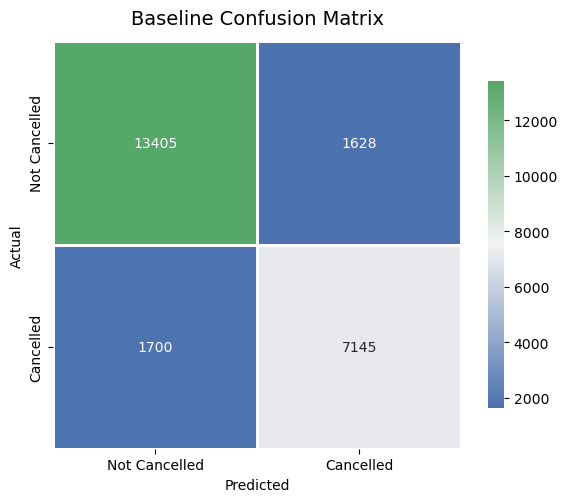

In [19]:
print(
    classification_report(
        y_test,
        baseline_test_prediction,
        target_names=["Not Cancelled", "Cancelled"],
        zero_division=0,
    )
)

cm_baseline = confusion_matrix(
    y_test,
    baseline_test_prediction,
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_baseline,
    annot=True,
    fmt="d",
    cmap=correlation_cmap,
    linewidths=1,
    linecolor="white",
    square=True,
    xticklabels=["Not Cancelled", "Cancelled"],
    yticklabels=["Not Cancelled", "Cancelled"],
    cbar_kws={"shrink": 0.8},
)

plt.title("Baseline Confusion Matrix", fontsize=14, pad=12)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### Baseline Error Profile

The baseline confusion matrix shows:

- **13,405** correctly identified non-cancellations,
- **1,628** false cancellation alerts,
- **1,700** missed cancellations,
- **7,145** correctly identified cancellations.

For the cancellation class, Precision is **0.8144** and Recall is **0.8078**, giving an F1 score of **0.8111**.

The two main error types are fairly close in size. False Negatives matter because they represent cancellations the model fails to flag, while False Positives matter because they would create unnecessary operational alerts. This balance becomes useful when comparing the tuned tree.

## 14. Hyperparameter Optimization with GridSearchCV

The baseline already shows what an unrestricted tree can do, so I use GridSearchCV to compare a smaller set of deliberately constrained alternatives.

The current search compares:

- split criterion,
- maximum depth,
- minimum samples required to split,
- minimum samples allowed in a leaf,
- and class weighting.

To keep the search practical in a local Jupyter environment, `ccp_alpha` is fixed at `0.0` in this reduced grid rather than being treated as an additional search dimension. Pruning was therefore not actively explored in this experiment.

`class_weight` is included because cancellations make up about 37% of the data and Recall has practical importance in this problem. Testing both `None` and `"balanced"` lets cross-validation determine whether automatic class reweighting improves the F1 objective.

The final grid contains **32 candidate configurations** and **160 cross-validation fits**.

In [20]:
param_grid = {
    "tree__criterion": ["gini", "entropy"],
    "tree__max_depth": [8, 12],
    "tree__min_samples_split": [10, 25],
    "tree__min_samples_leaf": [5, 10],
    "tree__ccp_alpha": [0.0],
    "tree__class_weight": [None, "balanced"],
}

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

n_candidates = int(
    np.prod([len(values) for values in param_grid.values()])
)

print(f"Candidate configurations: {n_candidates}")
print(
    f"Total CV fits: "
    f"{n_candidates * cv_strategy.get_n_splits()}"
)

grid_search = GridSearchCV(
    estimator=baseline_model,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="f1",
    n_jobs=1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid_search.best_params_)

print(
    f"Best Cross-Validated F1: "
    f"{grid_search.best_score_:.4f}"
)

Candidate configurations: 32
Total CV fits: 160
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Best Parameters:
{'tree__ccp_alpha': 0.0, 'tree__class_weight': None, 'tree__criterion': 'gini', 'tree__max_depth': 12, 'tree__min_samples_leaf': 5, 'tree__min_samples_split': 25}
Best Cross-Validated F1: 0.8040


### What GridSearchCV Selected

The best configuration from the **32 candidates tested** was:

- `criterion = "gini"`
- `max_depth = 12`
- `min_samples_leaf = 5`
- `min_samples_split = 25`
- `ccp_alpha = 0.0`
- `class_weight = None`

The best mean cross-validated F1 score was **0.8040**.

One thing worth noticing: three of the winning values sit at the edge of the grid. `max_depth = 12` is the deepest option tried, `min_samples_split = 25` is the largest split threshold, and `min_samples_leaf = 5` is the smallest leaf size. The true optimum may lie outside this small grid, so "tuned" here means the best of these 32 options, not the best possible tree.

The fact that `class_weight=None` was selected is a useful hint: in this search, automatically balancing the classes did **not** improve the F1 objective. That does not mean class weighting is never useful; it means the unweighted version performed better under this specific cross-validation setup and parameter grid.

The selected tree is then evaluated on the untouched test set rather than treating the cross-validation score as the final result.

## 15. Tuned Decision Tree Evaluation

In [21]:
tuned_model = grid_search.best_estimator_
tuned_test_prediction = tuned_model.predict(X_test)

tuned_metrics = pd.DataFrame(
    {
        "Model": ["Tuned Decision Tree"],
        "Accuracy": [accuracy_score(y_test, tuned_test_prediction)],
        "Precision": [precision_score(y_test, tuned_test_prediction)],
        "Recall": [recall_score(y_test, tuned_test_prediction)],
        "F1": [f1_score(y_test, tuned_test_prediction)],
    }
)

comparison = pd.concat(
    [baseline_metrics, tuned_metrics],
    ignore_index=True,
)

comparison

,Model,Accuracy,Precision,Recall,F1
0,Baseline Decision Tree,0.860625,0.814431,0.807801,0.811102
1,Tuned Decision Tree,0.858238,0.829790,0.776597,0.802313


In [22]:
tuned_train_prediction = tuned_model.predict(X_train)

baseline_train_f1 = f1_score( y_train, baseline_train_prediction, )
baseline_test_f1 = f1_score( y_test, baseline_test_prediction,)

tuned_train_f1 = f1_score( y_train, tuned_train_prediction,)
tuned_test_f1 = f1_score( y_test, tuned_test_prediction, )

generalization_comparison = pd.DataFrame(
    {
        "Model": [ "Baseline Decision Tree", "Tuned Decision Tree",],
        "Train F1": [ baseline_train_f1, tuned_train_f1,],
        "Test F1": [ baseline_test_f1, tuned_test_f1,],
        "F1 Gap": [ baseline_train_f1 - baseline_test_f1, tuned_train_f1 - tuned_test_f1,],
    })

baseline_tree = baseline_model.named_steps["tree"]
tuned_tree = tuned_model.named_steps["tree"]

complexity_comparison = pd.DataFrame(
    {
        "Model": [ "Baseline Decision Tree", "Tuned Decision Tree",],
        "Tree Depth": [ baseline_tree.get_depth(), tuned_tree.get_depth(),],
        "Number of Leaves": [ baseline_tree.get_n_leaves(), tuned_tree.get_n_leaves(),],
    })

print("Generalization comparison:")
display(generalization_comparison.round(4))

print("\nTree complexity comparison:")
display(complexity_comparison)

test_f1_change = tuned_test_f1 - baseline_test_f1

gap_change = ((tuned_train_f1 - tuned_test_f1) - (baseline_train_f1 - baseline_test_f1))

print(f"Test F1 change: {test_f1_change:+.4f}")
print(f"Train-test F1 gap change: {gap_change:+.4f}")

Generalization comparison:


,Model,Train F1,Test F1,F1 Gap
0,Baseline Decision Tree,0.9944,0.8111,0.1833
1,Tuned Decision Tree,0.8158,0.8023,0.0135



Tree complexity comparison:


,Model,Tree Depth,Number of Leaves
0,Baseline Decision Tree,49,10021
1,Tuned Decision Tree,12,418


Test F1 change: -0.0088
Train-test F1 gap change: -0.1698


### Generalization Versus Complexity

Tuning changes the model much more in **complexity** than in held-out F1.

The unrestricted tree has:

- **Depth:** 49
- **Leaves:** 10,021
- **Train F1:** 0.9944
- **Test F1:** 0.8111
- **F1 gap:** 0.1833

The tuned tree has:

- **Depth:** 12
- **Leaves:** 418
- **Train F1:** 0.8158
- **Test F1:** 0.8023
- **F1 gap:** 0.0135

The tuned model therefore reduces the train–test F1 gap by about **0.1698**, while Test F1 decreases by only **0.0088**.

This is the main modeling trade-off in the project: the tuned tree is dramatically smaller and much less separated between training and test performance, but it does not produce a higher held-out F1 score.

               precision    recall  f1-score   support

Not Cancelled       0.87      0.91      0.89     15033
    Cancelled       0.83      0.78      0.80      8845

     accuracy                           0.86     23878
    macro avg       0.85      0.84      0.85     23878
 weighted avg       0.86      0.86      0.86     23878



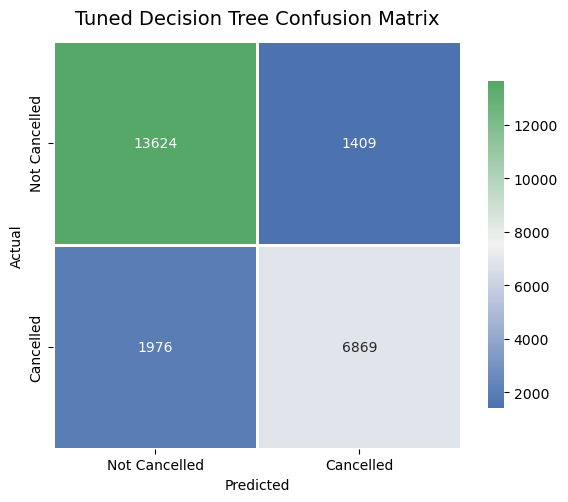

In [23]:
print(classification_report( y_test, tuned_test_prediction, target_names=["Not Cancelled", "Cancelled"], zero_division=0,))

cm_tuned = confusion_matrix( y_test, tuned_test_prediction,)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap=correlation_cmap,
    linewidths=1,
    linecolor="white",
    square=True,
    xticklabels=["Not Cancelled", "Cancelled"],
    yticklabels=["Not Cancelled", "Cancelled"],
    cbar_kws={"shrink": 0.8},
)

plt.title("Tuned Decision Tree Confusion Matrix", fontsize=14, pad=12)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### What Changed After Tuning

The tuned model shifts the error profile rather than improving every metric.

Compared with the baseline:

- **Precision** rises from 0.8144 to **0.8298**,
- **Recall** falls from 0.8078 to **0.7766**,
- **F1** falls from 0.8111 to **0.8023**,
- **Accuracy** changes only slightly, from 0.8606 to **0.8582**.

The confusion matrix makes that trade-off concrete:

- False Positives fall from **1,628 to 1,409**,
- False Negatives rise from **1,700 to 1,976**,
- True Positives fall from **7,145 to 6,869**.

So the tuned tree produces fewer false cancellation alerts, but it misses more actual cancellations.

This also helps interpret the GridSearch result: even though `class_weight="balanced"` was available, the best cross-validated F1 configuration still selected `class_weight=None`. Whether the tuned model is preferable therefore depends on the operational cost of false alerts versus missed cancellations, not on tuning alone.

## 16. Reading the Decision Tree

The full fitted tree is still too large to communicate clearly, even after tuning.

For interpretation, I display only the first three levels. This keeps the main decision path visible without pretending that the truncated picture is the complete model.

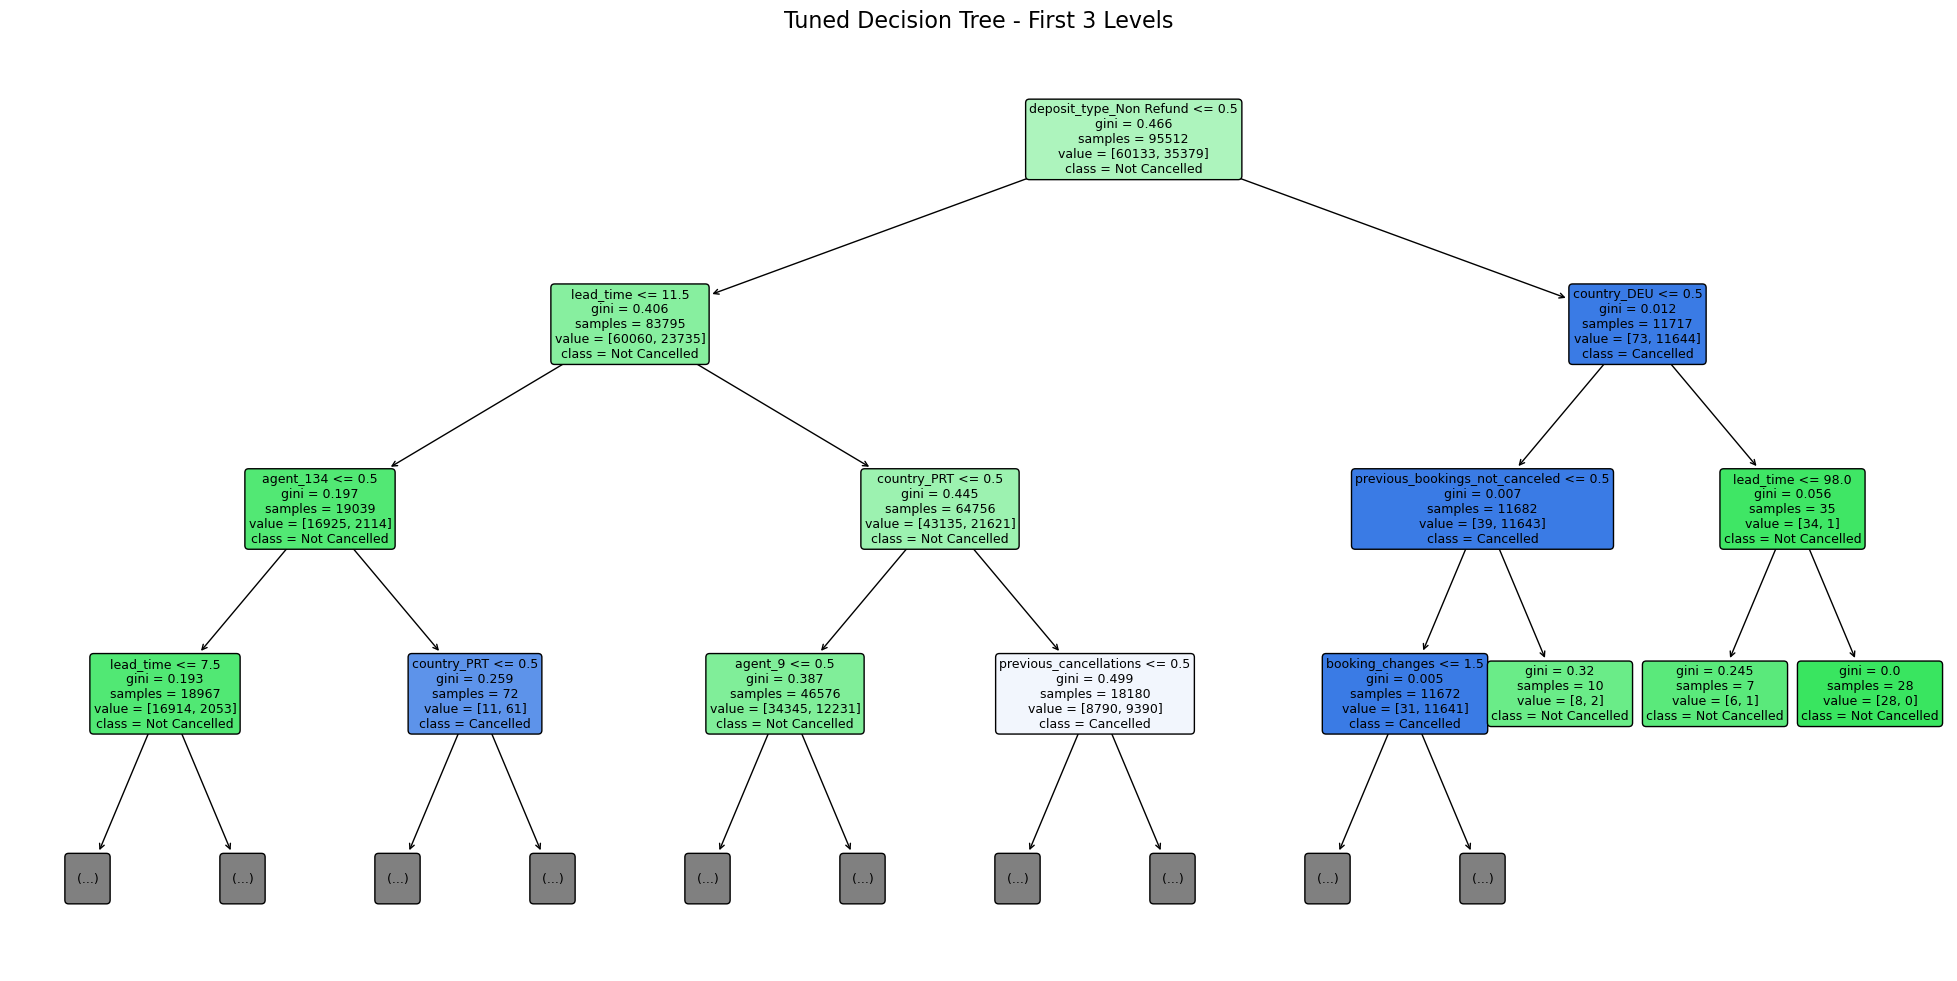

In [24]:
tuned_tree = tuned_model.named_steps["tree"]

feature_names = (tuned_model.named_steps["prep"].get_feature_names_out())

clean_feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in feature_names]

fig, ax = plt.subplots(figsize=(25, 12))

artists = plot_tree(
    tuned_tree,
    feature_names=clean_feature_names,
    class_names=["Not Cancelled", "Cancelled"],
    filled=True,
    max_depth=3,
    fontsize=9,
    rounded=True,
    ax=ax,
)

# Keep sklearn's purity shading, but use the portfolio green/blue hues.
not_cancelled_hue = colorsys.rgb_to_hsv(
    *to_rgb(SECONDARY)
)[0]
cancelled_hue = colorsys.rgb_to_hsv(
    *to_rgb(PRIMARY)
)[0]

for artist in artists:
    patch = artist.get_bbox_patch()

    if patch is None:
        continue

    label = artist.get_text()
    red, green, blue, alpha = patch.get_facecolor()
    hue, saturation, value = colorsys.rgb_to_hsv(
        red,
        green,
        blue,
    )

    if "class = Not Cancelled" in label:
        hue = not_cancelled_hue
    elif "class = Cancelled" in label:
        hue = cancelled_hue
    else:
        continue

    patch.set_facecolor(
        (*colorsys.hsv_to_rgb(hue, saturation, value), alpha)
    )

plt.title(
    "Tuned Decision Tree - First 3 Levels",
    fontsize=16,
    pad=14,
)
plt.show()

### Reading the First Three Levels

The root split is `deposit_type_Non Refund`, which is consistent with its dominant feature importance.

The right-hand branch deserves a closer look. It holds 11,717 training reservations, and 11,644 of them (about 99.4%) were cancelled. In everyday terms that looks backwards, since non-refundable bookings should be the ones people are least likely to abandon. It may reflect how this particular dataset was recorded rather than real guest behavior. The model uses the pattern because it is predictive here, but I would not expect it to carry over to another hotel or booking system without checking.

From there, the early branches use variables such as:

- `lead_time`,
- `country_DEU`,
- `agent_134`,
- `country_PRT`,
- `agent_9`,
- `previous_cancellations`,
- `previous_bookings_not_canceled`,
- and `booking_changes`.

The tree now uses agent IDs as One-Hot features such as `agent_9` rather than treating the raw ID as an ordered number. That is what I was hoping to see after converting `agent` to a categorical feature.

The presence of specific agent and country categories also reinforces the high-cardinality caveat: these splits can be informative here without necessarily transferring cleanly to another hotel system.

Only the first three levels are displayed for readability. The full tuned tree is still used for prediction, and these splits describe learned associations rather than causal effects.

## 17. Feature Importance

Decision Tree feature importance summarizes how much each transformed feature contributes to impurity reduction across the fitted tree.

I use it as a model-behavior diagnostic, not as a causal ranking.

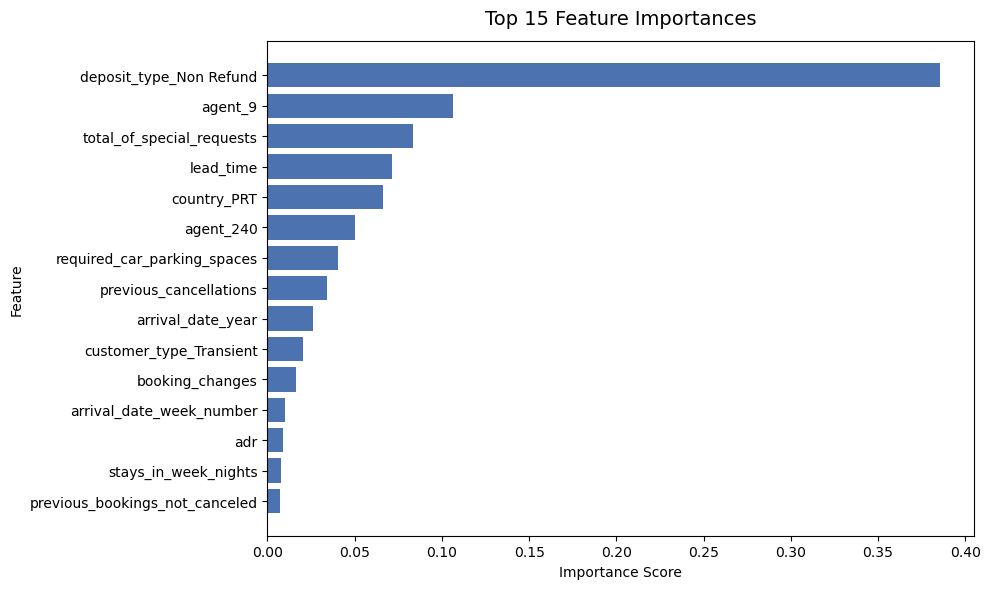

,Feature,Importance
234,deposit_type_Non Refund,0.385633
553,agent_9,0.106405
16,total_of_special_requests,0.083692
0,lead_time,0.071598
168,country_PRT,0.066356
336,agent_240,0.050129
15,required_car_parking_spaces,0.040437
10,previous_cancellations,0.034051
1,arrival_date_year,0.025985
566,customer_type_Transient,0.020502


In [25]:
importance_df = pd.DataFrame(
    {
        "Feature": clean_feature_names,
        "Importance": tuned_tree.feature_importances_,
    }
)

importance_df = (
    importance_df
    .sort_values("Importance", ascending=False)
    .head(15)
    .sort_values("Importance", ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"],
    color=PRIMARY,
)

plt.title("Top 15 Feature Importances", fontsize=14, pad=12)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

importance_df.sort_values(
    "Importance",
    ascending=False,
)

### What the Tree Relied On

The tuned tree is dominated by a small number of features.

The top five impurity-based importances are:

- `deposit_type_Non Refund` — **0.3856**
- `agent_9` — **0.1064**
- `total_of_special_requests` — **0.0837**
- `lead_time` — **0.0716**
- `country_PRT` — **0.0664**

`deposit_type_Non Refund` accounts for by far the largest share of impurity reduction and also appears at the root of the displayed tree.

At the same time, `agent_9`, `agent_240`, and `country_PRT` show why the high-cardinality features need cautious interpretation. Their importance can reflect patterns that are specific to this dataset rather than stable effects that would necessarily generalize to another property or booking system.

These are model-based importances, not causal effects.

Two more cautions. Impurity-based importance tends to favor features that offer many possible split points, so it is not a perfectly fair ranking across very different feature types. And `arrival_date_year` appears in the top ten (0.0260): with data covering only a few years, a year feature helps describe the past but cannot help with future arrivals.

## 18. Results

The final comparison tells a more useful story than a simple "tuned is better" conclusion.

| Metric | Baseline | Tuned |
|---|---:|---:|
| Accuracy | 0.8606 | 0.8582 |
| Precision | 0.8144 | 0.8298 |
| Recall | 0.8078 | 0.7766 |
| F1 | 0.8111 | 0.8023 |
| Train F1 | 0.9944 | 0.8158 |
| Test F1 | 0.8111 | 0.8023 |
| F1 Gap | 0.1833 | 0.0135 |
| Tree Depth | 49 | 12 |
| Leaves | 10,021 | 418 |

The tuned tree is much simpler and has a far smaller train–test gap, but its held-out F1 and Recall are slightly lower.

Its main test-set advantage is Precision: it generates fewer false cancellation alerts. The cost is lower Recall, meaning more actual cancellations are missed.

GridSearchCV also tested `class_weight="balanced"`, but the selected configuration used `class_weight=None`. In this experiment, automatic class balancing did not improve the cross-validated F1 objective.

The result is therefore a trade-off rather than a single winner. The more appropriate model depends on whether the operational priority is reducing false alerts, catching more cancellations, or favoring a simpler model with a much smaller generalization gap.

## 19. Conclusion

This project ended up being more about **model discipline** than about squeezing out one extra metric point.

The unrestricted Decision Tree achieves the stronger held-out F1 score (though duplicate rows may be flattering it), but it also grows to **49 levels and 10,021 leaves**, with a Train F1 of **0.9944** compared with **0.8111** on the test set. That is a clear overfitting signal.

The tuned tree reduces the structure to **12 levels and 418 leaves** and narrows the F1 gap from **0.1833 to 0.0135**. The trade-off is a small drop in Test F1 from **0.8111 to 0.8023** and a lower cancellation Recall of **0.7766**.

The error profile matters here. Tuning reduces false positives from **1,628 to 1,409**, but increases false negatives from **1,700 to 1,976**. In practice, the preferred model would depend on how the hotel values fewer unnecessary alerts versus fewer missed cancellations.

Several data decisions also remain explicit: direct outcome-leakage fields are removed, `assigned_room_type` is excluded because its scoring-time availability is uncertain, `company` is dropped because of identifier semantics and extreme missingness, and `agent` is treated as a categorical identifier.

The remaining limitations—exact duplicate rows without a unique booking ID and high-cardinality `agent`/`country` categories—are documented because they affect how confidently these results can be generalized beyond this dataset.

## 20. Future Improvements

The next experiments I would prioritize are:

- repeat the evaluation after removing exact duplicate rows as a sensitivity check,
- compare the current model with a version that includes `assigned_room_type` only if its scoring-time availability can be verified,
- use time-based validation once the deployment timeline is defined clearly,
- build a stricter booking-creation-only version with tighter feature-availability rules,
- group rare categories in high-cardinality features such as `agent` and `country`,
- compare One-Hot Encoding with leakage-safe frequency or target encoding,
- compare the single tree with Random Forest and Gradient Boosting,
- and explore probability thresholds when cancellation Recall is the main operational priority.

## 21. Technologies & Libraries

- Python
- pandas
- NumPy
- Matplotlib
- Seaborn
- scikit-learn
- Jupyter Notebook

## What I Learned

The most useful lesson from this project was that reducing overfitting does not automatically produce a higher test score.

The baseline tree had the better held-out F1 (a result I would want to re-check without duplicate rows), but a depth of **49**, more than **10,000 leaves**, and a **0.1833** Train–Test F1 gap made the overfitting problem hard to ignore. The tuned tree reduced that gap to **0.0135** and became dramatically smaller, even though its Test F1 fell slightly to **0.8023**.

I also saw why the error type matters as much as the headline metric. The tuned tree produced fewer false cancellation alerts, but it missed more real cancellations. That means model selection should be tied to operational costs rather than to whichever row has the highest score.

Testing `class_weight` was useful for the same reason. `"balanced"` sounded reasonable because the cancellation class is smaller, but cross-validation still selected `class_weight=None`. That was a good reminder that a sensible idea still needs evidence from the actual data.

Feature representation mattered too. `agent` looks numerical in the CSV, but it is really an identifier. Converting it to a categorical feature removed artificial numeric ordering, while the resulting high-cardinality One-Hot features introduced a different limitation that needs to be acknowledged.

Finally, `assigned_room_type` reinforced the importance of feature timing. A feature can be predictive and still be a poor choice if its availability at the intended scoring point cannot be defended clearly.

The habit I want to keep from this project is simple: make each modeling decision explicit, check what changed after it, and let the evidence—not the tuning step itself—drive the conclusion.

## Visualization Notes

The charts use a consistent portfolio color palette for readability:

- `PRIMARY = #4C72B0`
- `SECONDARY = #55A868`
- `ACCENT = #C44E52`
- `NEUTRAL = #7F7F7F`

The correlation matrix uses the shared blue–neutral–green colormap, and the Decision Tree uses green for **Not Cancelled** and blue for **Cancelled**. The colors are only a visual aid; they do not change the model output. One inconsistency to be aware of: the class-distribution bar chart in Section 6.1 uses blue for Not Cancelled and green for Cancelled, the reverse of the tree plot.

## Project Links

This notebook is part of my machine learning portfolio.

- **GitHub Profile:** [Anahita-Pouladi](https://github.com/Anahita-Pouladi)
- **Kaggle Profile:** [anahitapouladi](https://www.kaggle.com/anahitapouladi)

### Project Pages

- **GitHub Repository:** To be added after the repository is published
- **Kaggle Notebook:** To be added after the Kaggle notebook is published

Once both project pages are live, these two placeholders should be replaced with the final project-specific URLs.